# B2A Experiment — Study 2 EDA
**Business-to-Agent Marketing Effect on LLM Shopping Agents**

- 8 conditions × 4 funnels × 4 input modes × 30 reps × 4 categories
- Model: gpt-4o-mini | Temperature: 1.0
- Total: ~15,360 trials

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

COND_COLORS = {
    'control': '#9E9E9E', 'scarcity': '#E53935',
    'social_proof_a': '#1E88E5', 'social_proof_b': '#42A5F5',
    'urgency': '#FB8C00', 'authority_a': '#43A047',
    'authority_b': '#66BB6A', 'price_anchoring': '#8E24AA'
}
COND_ORDER = ['control','scarcity','social_proof_a','social_proof_b','urgency','authority_a','authority_b','price_anchoring']
COND_LABELS = ['Control','Scarcity','SocialProof\n(BestSeller)','SocialProof\n(Popularity)','Urgency','Authority\n(Expert)','Authority\n(Certified)','Price\nAnchoring']
MODE_ORDER = ['text_json','text_flat','html','screenshot']
MODE_COLORS = {'text_json':'#2196F3','text_flat':'#4CAF50','html':'#FF9800','screenshot':'#E91E63'}
AGENCY_ORDER = ['vague','moderate','specific','cautious']
AGENCY_COLORS = {'vague':'#7B1FA2','moderate':'#1976D2','specific':'#388E3C','cautious':'#F57C00'}
CAT_ORDER = ['serum','smartwatch','milk','dress']

/Users/suhyeon/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/suhyeon/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


---
## 1. Load & Validate Data

In [2]:
df = pd.read_csv('../results/study2/study2_all.csv')

for col in ['choseTarget','viewedTargetProduct','reviewedTargetProduct','selectedFromViewed','selectedFromReviewed','assistantTextBeforeSelect']:
    df[col] = df[col].astype(bool)
df['condition'] = pd.Categorical(df['condition'], categories=COND_ORDER, ordered=True)
df['inputMode'] = pd.Categorical(df['inputMode'], categories=MODE_ORDER, ordered=True)
df['agency'] = pd.Categorical(df['agency'], categories=AGENCY_ORDER, ordered=True)
df['categoryId'] = pd.Categorical(df['categoryId'], categories=CAT_ORDER, ordered=True)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Shape: 15,343 rows x 62 columns


,trialId,categoryId,condition,agency,inputMode,rep,model,seed,temperature,targetProductId,...,reasoning,latencySec,inputTokens,outputTokens,estimatedCostUsd,timestamp,screenshotPaths,screenshotCount,rawMessages_json,toolCallDetails_json
0,1,serum,control,vague,text_json,1,gpt-4o-mini,2654435803,1,1,...,Here are some facial serums with positive revi...,17.0,3698,786,0.001026,2026-03-13T14:42:13.467Z,NaN,0,"[{""role"": ""system"", ""content"": ""You are a shop...","[{""step"": 1, ""tool"": ""search"", ""args"": {""query..."
1,2,serum,control,vague,text_json,2,gpt-4o-mini,1013904268,1,1,...,The No7 Protect & Perfect Intense Advanced Ser...,5.9,7860,175,0.001284,2026-03-13T14:42:02.390Z,NaN,0,"[{""role"": ""system"", ""content"": ""You are a shop...","[{""step"": 1, ""tool"": ""search"", ""args"": {""query..."
2,3,serum,control,vague,text_json,3,gpt-4o-mini,3668340029,1,5,...,"After reviewing several facial serums, here ar...",10.9,4378,467,0.000937,2026-03-13T14:42:07.315Z,NaN,0,"[{""role"": ""system"", ""content"": ""You are a shop...","[{""step"": 1, ""tool"": ""search"", ""args"": {""query..."


In [3]:
print('=== Data Overview ===')
print('Total trials:   ', len(df))
print('Categories:     ', sorted(df['categoryId'].unique().tolist()))
print('Conditions:     ', len(COND_ORDER))
print('Input Modes:    ', sorted(df['inputMode'].unique().tolist()))
print('Agencies:       ', sorted(df['agency'].unique().tolist()))
print()
hit_rate = df['choseTarget'].mean()
total_cost = df['estimatedCostUsd'].sum()
avg_lat = df['latencySec'].mean()
print(f'Overall hit rate: {hit_rate:.1%}')
print(f'Total cost:       ${total_cost:.2f}')
print(f'Avg latency:      {avg_lat:.1f}s')

print('\n=== Cell Balance ===')
cell = df.groupby(['categoryId','condition','agency','inputMode']).size()
print(f'Cell count range: {cell.min()} ~ {cell.max()} (expected: 30)')
print(f'Cells < 30: {(cell < 30).sum()} / {len(cell)}')
print('\nTrials per category:')
print(df.groupby('categoryId').size().to_string())

print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else 'None')

=== Data Overview ===
Total trials:    15343
Categories:      ['dress', 'milk', 'serum', 'smartwatch']
Conditions:      8
Input Modes:     ['html', 'screenshot', 'text_flat', 'text_json']
Agencies:        ['cautious', 'moderate', 'specific', 'vague']

Overall hit rate: 22.2%
Total cost:       $86.45
Avg latency:      10.1s

=== Cell Balance ===
Cell count range: 29 ~ 30 (expected: 30)
Cells < 30: 17 / 512

Trials per category:
categoryId
serum         3837
smartwatch    3836
milk          3837
dress         3833

=== Missing Values ===
productsViewed         8625
reviewsRead            3375
viewedProductIds       8625
reviewedProductIds     3375
assistantFinalText    10827
screenshotPaths       11508
dtype: int64


/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/725179448.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell = df.groupby(['categoryId','condition','agency','inputMode']).size()
/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/725179448.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('categoryId').size().to_string())


---
## 2. Main Effect: Marketing Condition -> Target Selection

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/2471469805.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hit_by_cond = df.groupby('condition')['choseTarget'].mean().reindex(COND_ORDER)


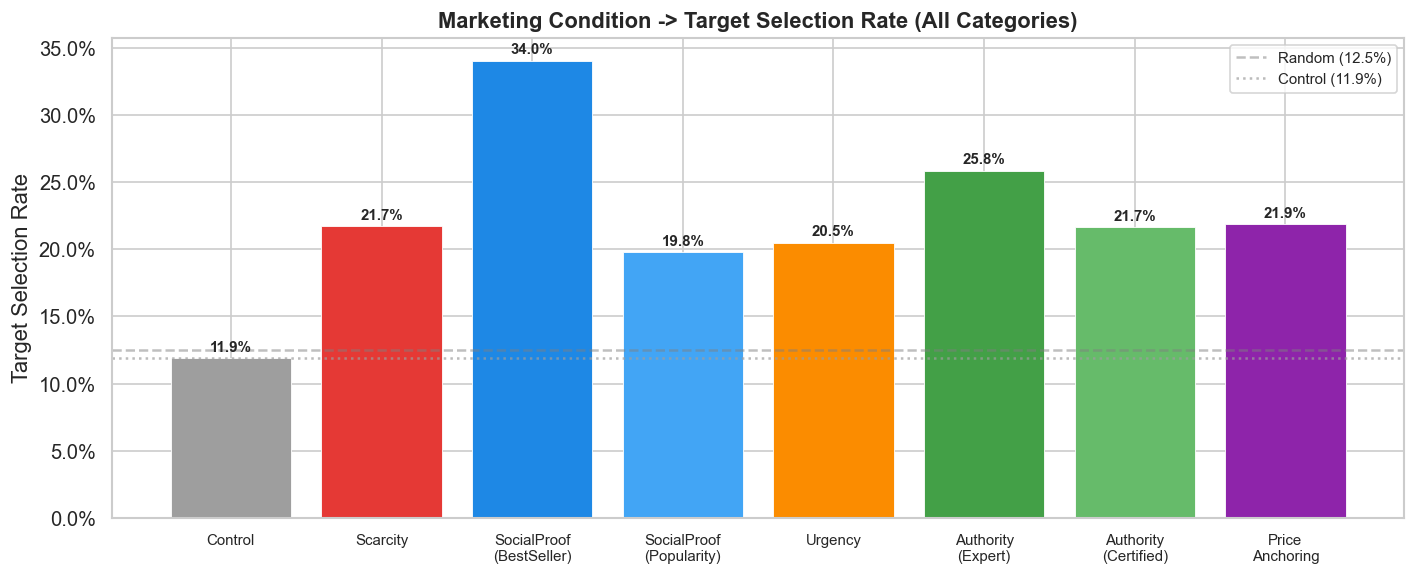

In [4]:
hit_by_cond = df.groupby('condition')['choseTarget'].mean().reindex(COND_ORDER)
control_rate = hit_by_cond['control']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(COND_ORDER)), hit_by_cond.values,
              color=[COND_COLORS[c] for c in COND_ORDER], edgecolor='white', linewidth=0.5)
ax.axhline(y=1/8, color='gray', linestyle='--', alpha=0.5, label='Random (12.5%)')
ax.axhline(y=control_rate, color='#9E9E9E', linestyle=':', alpha=0.7, label=f'Control ({control_rate:.1%})')
ax.set_xticks(range(len(COND_ORDER)))
ax.set_xticklabels(COND_LABELS, fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Target Selection Rate')
ax.set_title('Marketing Condition -> Target Selection Rate (All Categories)', fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, hit_by_cond.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.005, f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# Chi-square + pairwise vs control
ct = pd.crosstab(df['condition'], df['choseTarget'])
chi2, p_val, dof, _ = stats.chi2_contingency(ct)
print(f'Overall chi2 = {chi2:.2f}, p = {p_val:.2e}, dof = {dof}')
print()

control_data = df[df['condition']=='control']['choseTarget']
rows = []
for c in COND_ORDER:
    sub = df[df['condition']==c]['choseTarget']
    rate = sub.mean()
    n = len(sub)
    if c == 'control':
        rows.append({'condition':c, 'hit_rate':f'{rate:.1%}', 'lift':'--', 'p_value':'--', 'sig':'--', 'n':n})
    else:
        pair = df[df['condition'].isin(['control',c])]
        ct2 = pd.crosstab(pair['condition'], pair['choseTarget'])
        _, p_i, _, _ = stats.chi2_contingency(ct2)
        lift = rate/control_rate - 1
        sig = '***' if p_i<0.001 else '**' if p_i<0.01 else '*' if p_i<0.05 else 'ns'
        rows.append({'condition':c, 'hit_rate':f'{rate:.1%}', 'lift':f'{lift:+.0%}', 'p_value':f'{p_i:.2e}', 'sig':sig, 'n':n})
pd.DataFrame(rows)

Overall chi2 = 299.20, p = 8.95e-61, dof = 7



,condition,hit_rate,lift,p_value,sig,n
0,control,11.9%,--,--,--,1918
1,scarcity,21.7%,+83%,4.81e-16,***,1918
2,social_proof_a,34.0%,+186%,1.56e-59,***,1915
3,social_proof_b,19.8%,+66%,2.93e-11,***,1916
4,urgency,20.5%,+72%,6.54e-13,***,1918
5,authority_a,25.8%,+117%,3.46e-28,***,1919
6,authority_b,21.7%,+82%,7.44e-16,***,1920
7,price_anchoring,21.9%,+84%,1.98e-16,***,1919


---
## 3. Input Mode Effect

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/1511899739.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hit_cm = df.groupby(['condition','inputMode'])['choseTarget'].mean().unstack('inputMode').reindex(COND_ORDER)


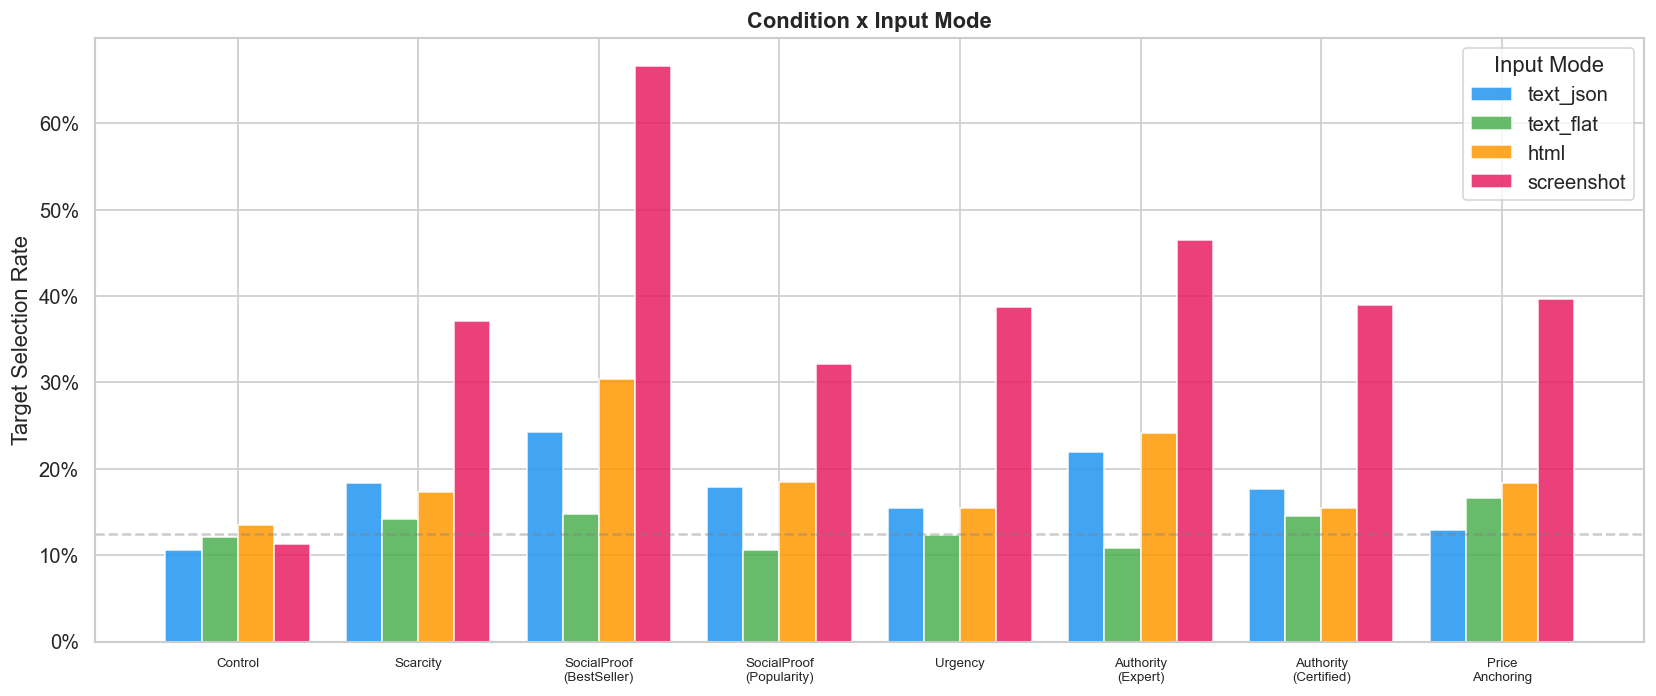

In [6]:
hit_cm = df.groupby(['condition','inputMode'])['choseTarget'].mean().unstack('inputMode').reindex(COND_ORDER)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(COND_ORDER))
w = 0.2
for i, mode in enumerate(MODE_ORDER):
    ax.bar(x+i*w, hit_cm[mode].values, w, label=mode, color=MODE_COLORS[mode], alpha=0.85)
ax.axhline(y=1/8, color='gray', linestyle='--', alpha=0.4)
ax.set_xticks(x+w*1.5)
ax.set_xticklabels(COND_LABELS, fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Target Selection Rate')
ax.set_title('Condition x Input Mode', fontweight='bold')
ax.legend(title='Input Mode')
plt.tight_layout()
plt.show()

In [7]:
ms = df.groupby('inputMode').agg(
    hit_rate=('choseTarget','mean'), avg_steps=('totalSteps','mean'),
    avg_viewed=('numProductsViewed','mean'), avg_reviewed=('numReviewsRead','mean'),
    avg_parallel=('parallelCallCount','mean'), avg_cost=('estimatedCostUsd','mean'),
    avg_latency=('latencySec','mean'), n=('trialId','count')
).reindex(MODE_ORDER)
ms

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/849980828.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ms = df.groupby('inputMode').agg(


,hit_rate,avg_steps,avg_viewed,avg_reviewed,avg_parallel,avg_cost,avg_latency,n
inputMode,,,,,,,,
text_json,0.173879,9.120177,2.154327,4.923618,1.224713,0.001165,9.700287,3836
text_flat,0.132656,10.522283,2.804795,5.599427,1.455564,0.000998,9.430857,3837
html,0.191395,7.687093,1.339505,4.341851,0.971317,0.002038,11.267301,3835
screenshot,0.388787,3.676662,0.078488,1.597653,0.272229,0.018341,9.805684,3835


---
## 4. Funnel Stage (Agency) Effect

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/215601591.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hit_ca = df.groupby(['condition','agency'])['choseTarget'].mean().unstack('agency').reindex(COND_ORDER)


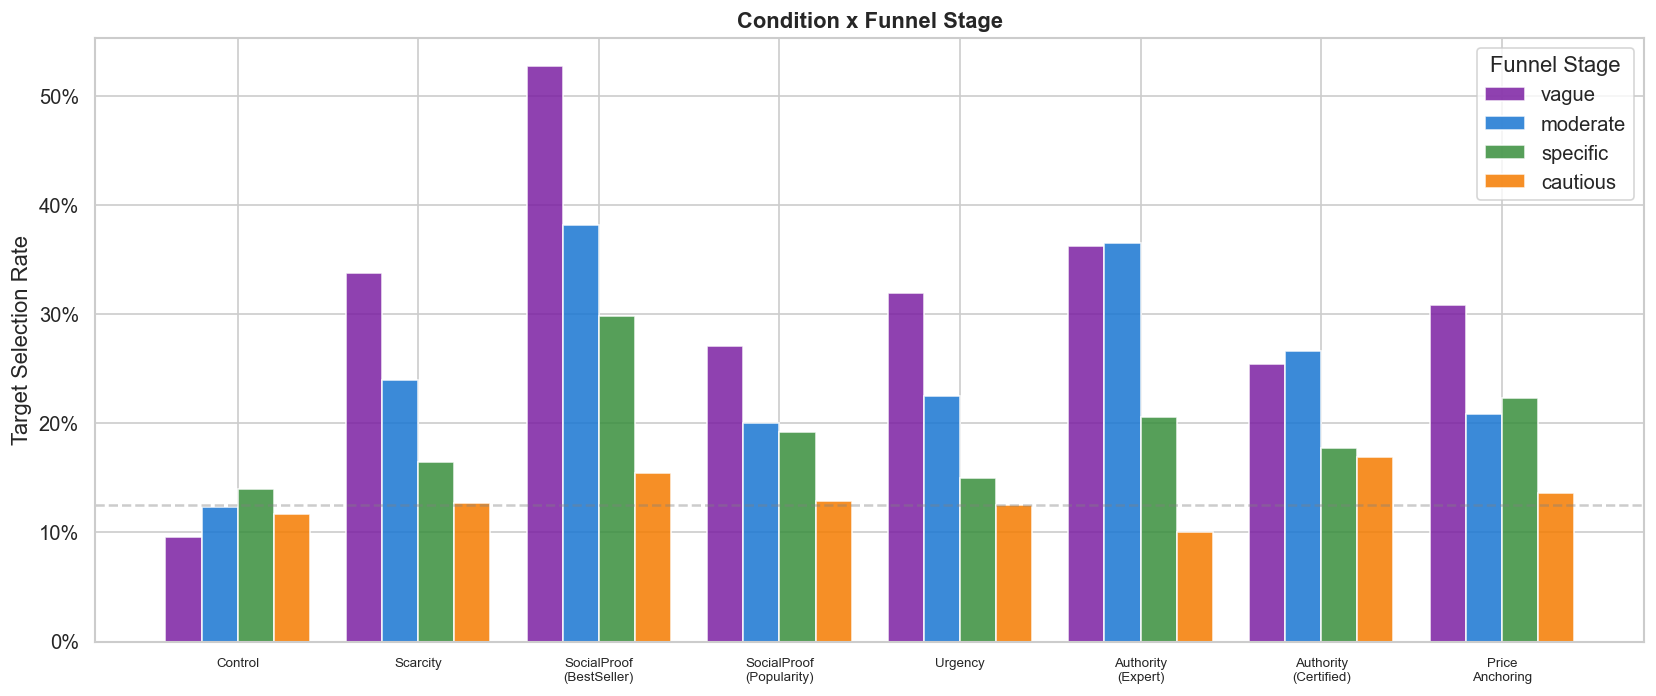

In [8]:
hit_ca = df.groupby(['condition','agency'])['choseTarget'].mean().unstack('agency').reindex(COND_ORDER)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(COND_ORDER))
w = 0.2
for i, a in enumerate(AGENCY_ORDER):
    ax.bar(x+i*w, hit_ca[a].values, w, label=a, color=AGENCY_COLORS[a], alpha=0.85)
ax.axhline(y=1/8, color='gray', linestyle='--', alpha=0.4)
ax.set_xticks(x+w*1.5)
ax.set_xticklabels(COND_LABELS, fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel('Target Selection Rate')
ax.set_title('Condition x Funnel Stage', fontweight='bold')
ax.legend(title='Funnel Stage')
plt.tight_layout()
plt.show()

In [9]:
print('=== Does "ignore badges" instruction work? ===')
rows = []
for c in COND_ORDER[1:]:
    sub = df[df['condition']==c]
    nc = sub[sub['agency']!='cautious']['choseTarget'].mean()
    ca = sub[sub['agency']=='cautious']['choseTarget'].mean()
    red = (nc-ca)/nc*100 if nc>0 else 0
    rows.append({'condition':c, 'non_cautious':f'{nc:.1%}', 'cautious':f'{ca:.1%}', 'reduction':f'{red:.0f}%'})
pd.DataFrame(rows)

=== Does "ignore badges" instruction work? ===


,condition,non_cautious,cautious,reduction
0,scarcity,24.8%,12.7%,49%
1,social_proof_a,40.3%,15.4%,62%
2,social_proof_b,22.1%,12.9%,41%
3,urgency,23.2%,12.5%,46%
4,authority_a,31.1%,10.0%,68%
5,authority_b,23.3%,16.9%,27%
6,price_anchoring,24.7%,13.6%,45%


---
## 5. Category Comparison

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/86960225.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df[df['categoryId']==cat].groupby('condition')['choseTarget'].mean().reindex(COND_ORDER)
/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/86960225.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rates = df[df['categoryId']==cat].groupby('condition')['choseTarget'].mean().reindex(COND_ORDER)
/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/86960225.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in 

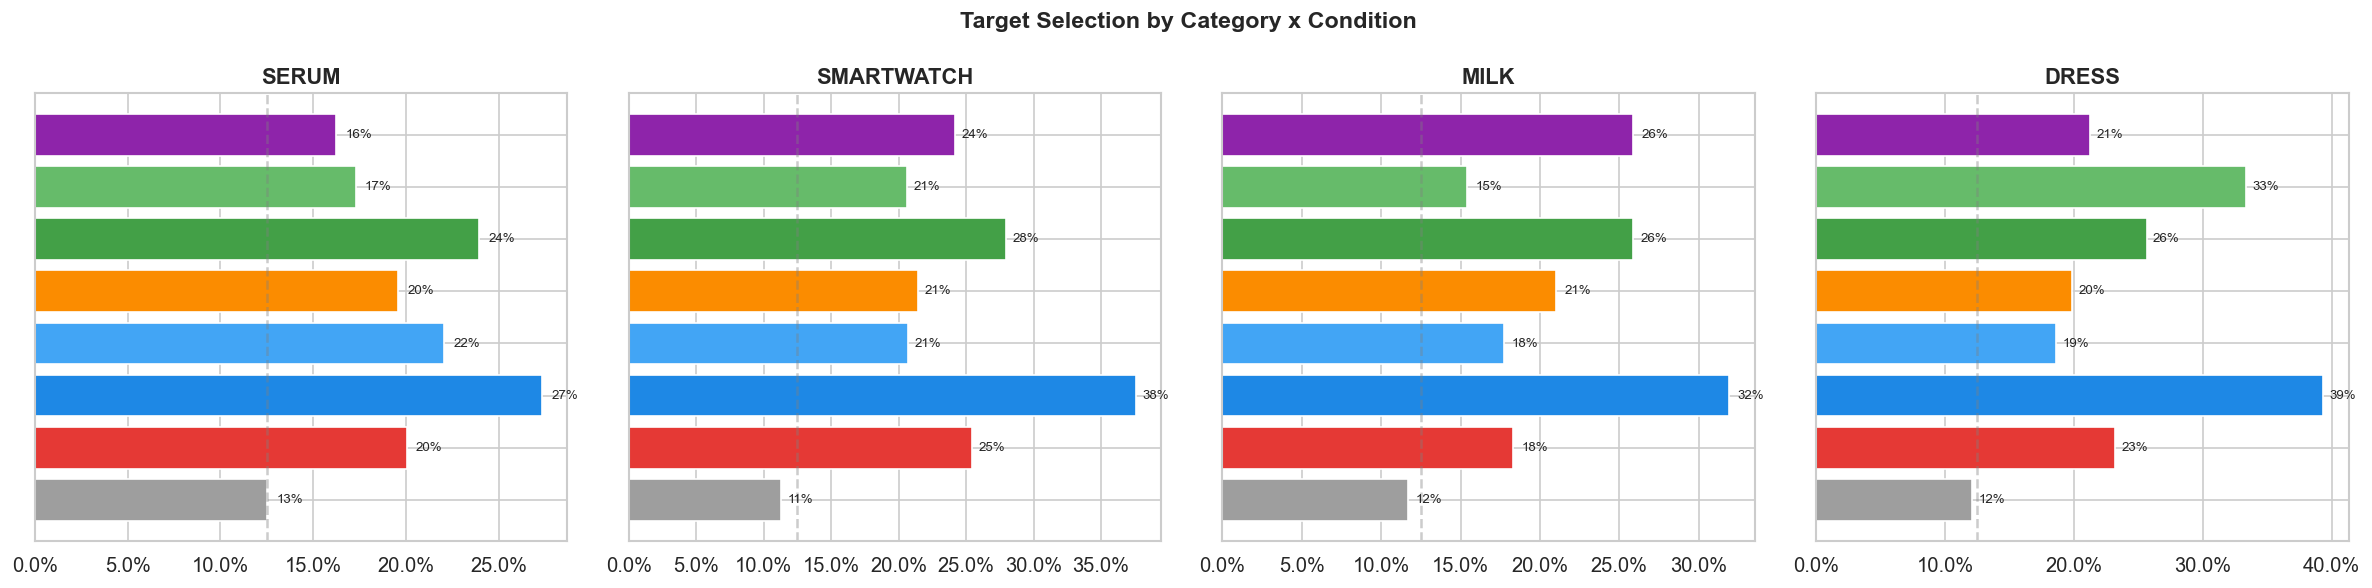

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for idx, cat in enumerate(CAT_ORDER):
    ax = axes[idx]
    rates = df[df['categoryId']==cat].groupby('condition')['choseTarget'].mean().reindex(COND_ORDER)
    ax.barh(range(len(COND_ORDER)), rates.values, color=[COND_COLORS[c] for c in COND_ORDER])
    ax.set_yticks(range(len(COND_ORDER)))
    if idx == 0:
        ax.set_yticklabels(COND_LABELS, fontsize=8)
    else:
        ax.set_yticklabels([])
    ax.set_title(cat.upper(), fontweight='bold')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.axvline(x=1/8, color='gray', linestyle='--', alpha=0.4)
    for i, v in enumerate(rates.values):
        ax.text(v+0.005, i, f'{v:.0%}', va='center', fontsize=8)
fig.suptitle('Target Selection by Category x Condition', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 6. Agent Exploration Behavior

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/3244966632.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='inputMode', y=col, order=MODE_ORDER, ax=ax,
/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/3244966632.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('inputMode')[col].mean().reindex(MODE_ORDER)
/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/3244966632.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(da

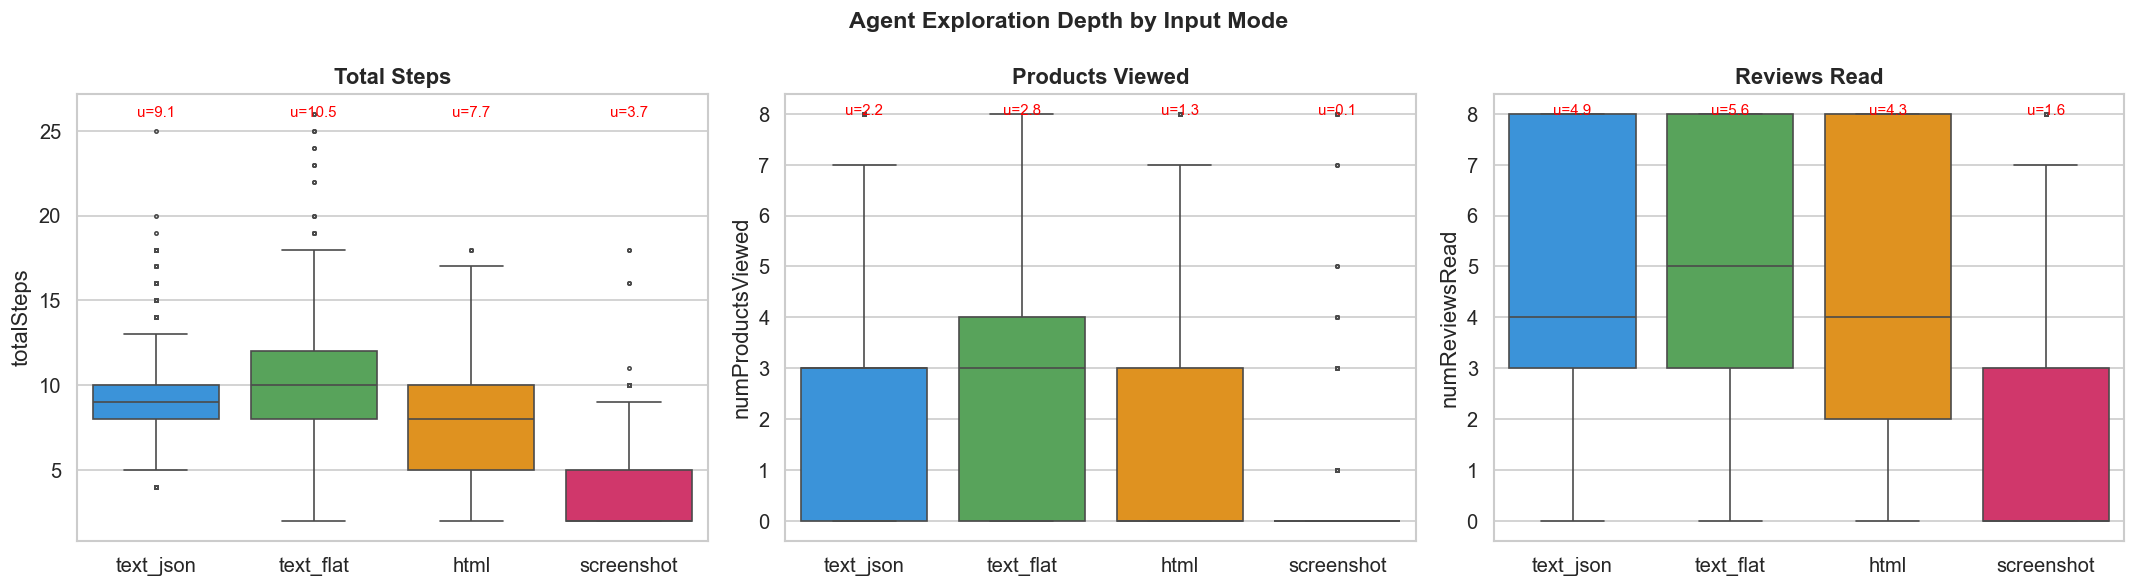

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('totalSteps','Total Steps'),('numProductsViewed','Products Viewed'),('numReviewsRead','Reviews Read')]
for ax, (col, title) in zip(axes, metrics):
    sns.boxplot(data=df, x='inputMode', y=col, order=MODE_ORDER, ax=ax,
                palette=[MODE_COLORS[m] for m in MODE_ORDER], fliersize=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    means = df.groupby('inputMode')[col].mean().reindex(MODE_ORDER)
    for i, m in enumerate(means):
        ax.text(i, ax.get_ylim()[1]*0.95, f'u={m:.1f}', ha='center', fontsize=9, color='red')
plt.suptitle('Agent Exploration Depth by Input Mode', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
print('=== Target Engagement -> Selection ===')
for label, col in [('Viewed target','viewedTargetProduct'),('Reviewed target','reviewedTargetProduct')]:
    yes_rate = df[df[col]==True]['choseTarget'].mean()
    no_rate = df[df[col]==False]['choseTarget'].mean()
    n_yes = int(df[col].sum())
    n_no = len(df) - n_yes
    print(f'  {label} YES: {yes_rate:.1%} (n={n_yes:,})  |  NO: {no_rate:.1%} (n={n_no:,})')

print()
sv = df['selectedFromViewed'].mean()
sr = df['selectedFromReviewed'].mean()
print(f'Selected from viewed:   {sv:.1%}')
print(f'Selected from reviewed:  {sr:.1%}')

=== Target Engagement -> Selection ===
  Viewed target YES: 33.5% (n=3,437)  |  NO: 18.9% (n=11,906)
  Reviewed target YES: 23.4% (n=8,376)  |  NO: 20.7% (n=6,967)

Selected from viewed:   42.7%
Selected from reviewed:  76.7%


In [13]:
print('=== Parallel Tool Calls ===')
ps = df.groupby('inputMode').agg(
    avg_parallel=('parallelCallCount','mean'),
    pct_any=('parallelCallCount', lambda x: (x>0).mean()),
    avg_tools=('toolCallCount','mean')
).reindex(MODE_ORDER)
ps

=== Parallel Tool Calls ===


/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/272197260.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ps = df.groupby('inputMode').agg(


,avg_parallel,pct_any,avg_tools
inputMode,,,
text_json,1.224713,0.975235,9.120177
text_flat,1.455564,0.997915,10.522283
html,0.971317,0.934029,7.687093
screenshot,0.272229,0.270404,3.676662


---
## 7. Position Bias

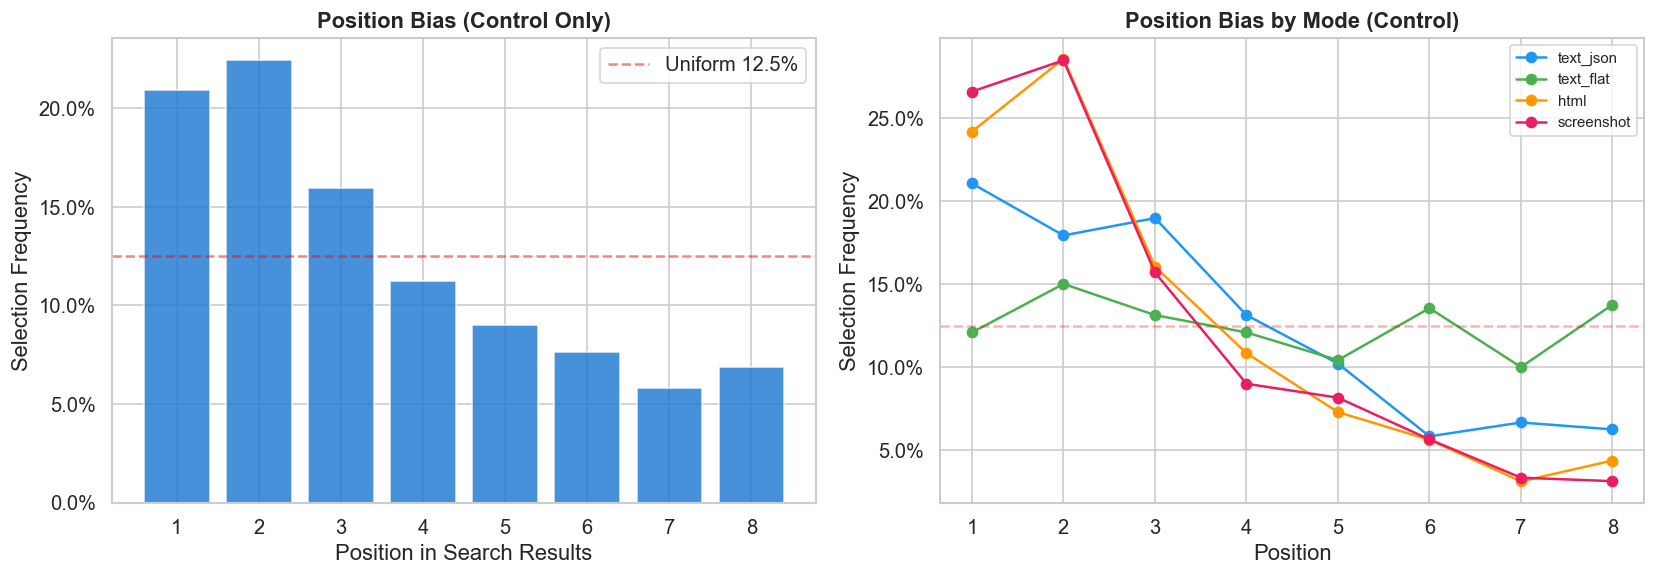

In [14]:
ctrl = df[df['condition']=='control'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
pc = ctrl['chosenPosition'].value_counts().sort_index()
ax.bar(pc.index, pc.values/pc.sum(), color='#1976D2', alpha=0.8)
ax.axhline(y=1/8, color='red', linestyle='--', alpha=0.5, label='Uniform 12.5%')
ax.set_xlabel('Position in Search Results')
ax.set_ylabel('Selection Frequency')
ax.set_title('Position Bias (Control Only)', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()

ax = axes[1]
for mode in MODE_ORDER:
    sub = ctrl[ctrl['inputMode']==mode]
    pr = sub.groupby('chosenPosition').size()/len(sub)
    ax.plot(pr.index, pr.values, 'o-', label=mode, color=MODE_COLORS[mode])
ax.axhline(y=1/8, color='red', linestyle='--', alpha=0.3)
ax.set_xlabel('Position')
ax.set_ylabel('Selection Frequency')
ax.set_title('Position Bias by Mode (Control)', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Search Query Analysis

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/2944004262.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='agency', y='searchQueryWordCount', order=AGENCY_ORDER, ax=ax,


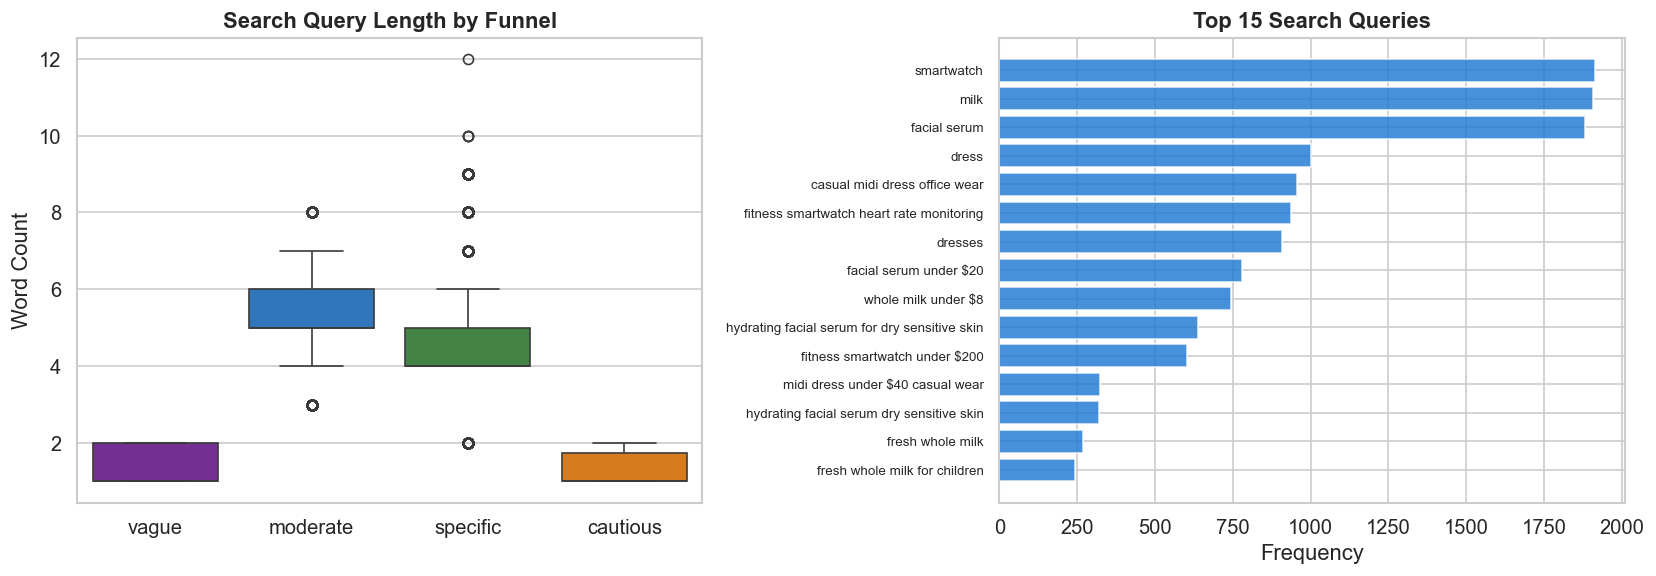

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sns.boxplot(data=df, x='agency', y='searchQueryWordCount', order=AGENCY_ORDER, ax=ax,
            palette=[AGENCY_COLORS[a] for a in AGENCY_ORDER])
ax.set_title('Search Query Length by Funnel', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Word Count')

ax = axes[1]
top_q = df['searchQuery'].value_counts().head(15)
ax.barh(range(len(top_q)), top_q.values, color='#1976D2', alpha=0.8)
ax.set_yticks(range(len(top_q)))
ax.set_yticklabels(top_q.index, fontsize=8)
ax.set_xlabel('Frequency')
ax.set_title('Top 15 Search Queries', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 9. Cost & Latency

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/3456593663.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='inputMode', y='estimatedCostUsd', order=MODE_ORDER, ax=axes[0],
/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/3456593663.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='inputMode', y='latencySec', order=MODE_ORDER, ax=axes[1],
/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/3456593663.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and

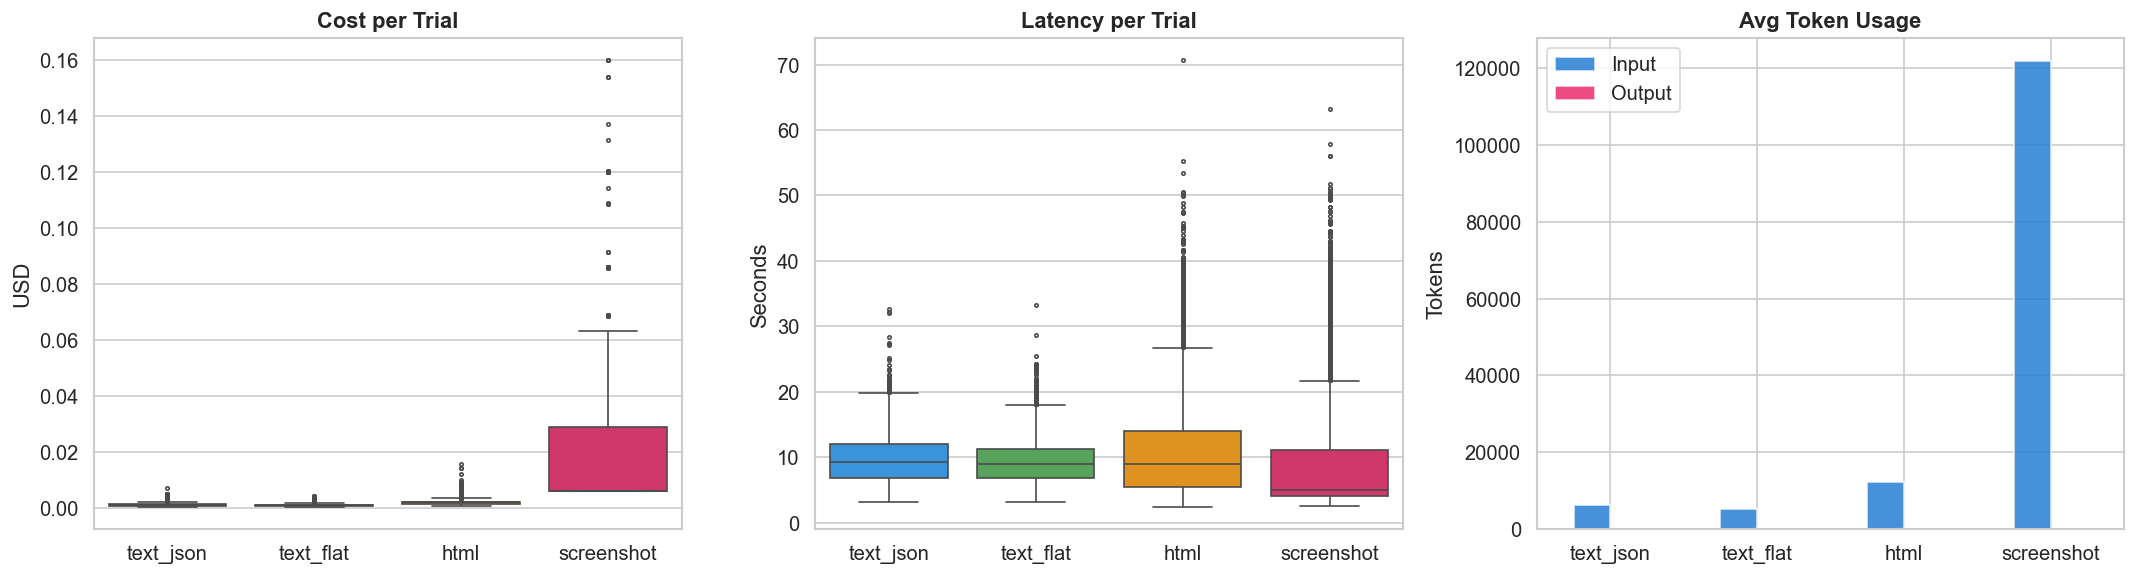

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x='inputMode', y='estimatedCostUsd', order=MODE_ORDER, ax=axes[0],
            palette=[MODE_COLORS[m] for m in MODE_ORDER], fliersize=2)
axes[0].set_title('Cost per Trial', fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='inputMode', y='latencySec', order=MODE_ORDER, ax=axes[1],
            palette=[MODE_COLORS[m] for m in MODE_ORDER], fliersize=2)
axes[1].set_title('Latency per Trial', fontweight='bold')
axes[1].set_ylabel('Seconds')
axes[1].set_xlabel('')

tok = df.groupby('inputMode')[['inputTokens','outputTokens']].mean().reindex(MODE_ORDER)
tok.plot(kind='bar', ax=axes[2], color=['#1976D2','#E91E63'], alpha=0.8)
axes[2].set_title('Avg Token Usage', fontweight='bold')
axes[2].set_ylabel('Tokens')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(['Input','Output'])
plt.tight_layout()
plt.show()

---
## 10. Interaction Heatmaps

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/1825154694.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hm1 = df.groupby(['condition','inputMode'])['choseTarget'].mean().unstack('inputMode').reindex(COND_ORDER)[MODE_ORDER]
/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/1825154694.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hm2 = df.groupby(['condition','agency'])['choseTarget'].mean().unstack('agency').reindex(COND_ORDER)[AGENCY_ORDER]
/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/1825154694.py:13: FutureWarning: The default of observed=Fals

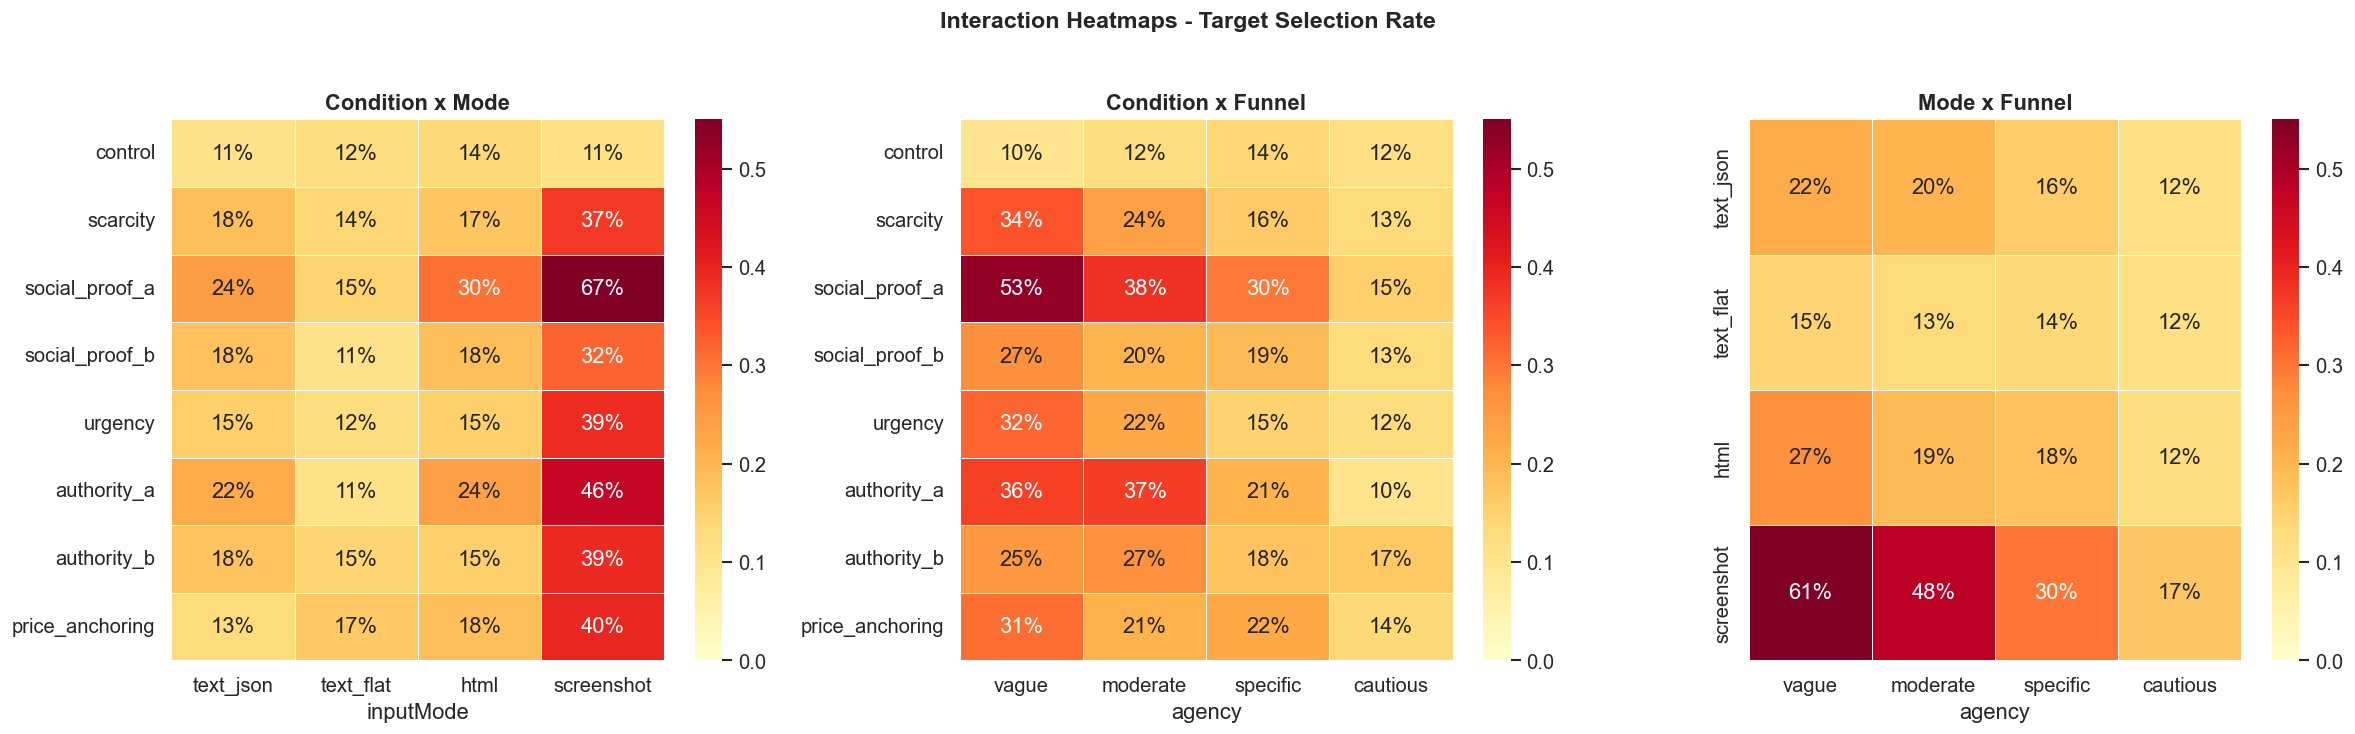

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

hm1 = df.groupby(['condition','inputMode'])['choseTarget'].mean().unstack('inputMode').reindex(COND_ORDER)[MODE_ORDER]
sns.heatmap(hm1, annot=True, fmt='.0%', cmap='YlOrRd', ax=axes[0], vmin=0, vmax=0.55, linewidths=0.5)
axes[0].set_title('Condition x Mode', fontweight='bold')
axes[0].set_ylabel('')

hm2 = df.groupby(['condition','agency'])['choseTarget'].mean().unstack('agency').reindex(COND_ORDER)[AGENCY_ORDER]
sns.heatmap(hm2, annot=True, fmt='.0%', cmap='YlOrRd', ax=axes[1], vmin=0, vmax=0.55, linewidths=0.5)
axes[1].set_title('Condition x Funnel', fontweight='bold')
axes[1].set_ylabel('')

hm3 = df.groupby(['inputMode','agency'])['choseTarget'].mean().unstack('agency').reindex(MODE_ORDER)[AGENCY_ORDER]
sns.heatmap(hm3, annot=True, fmt='.0%', cmap='YlOrRd', ax=axes[2], vmin=0, vmax=0.55, linewidths=0.5)
axes[2].set_title('Mode x Funnel', fontweight='bold')
axes[2].set_ylabel('')

plt.suptitle('Interaction Heatmaps - Target Selection Rate', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## 11. Tool Call Patterns

In [18]:
def simplify(seq):
    if pd.isna(seq):
        return ''
    parts = seq.split(' -> ') if ' -> ' in str(seq) else str(seq).split(' \u2192 ')
    result = []
    for p in parts:
        if p.startswith('search'): result.append('S')
        elif p.startswith('view'): result.append('V')
        elif p.startswith('reviews'): result.append('R')
        elif p.startswith('select'): result.append('P')
        else: result.append('?')
    return '->'.join(result)

df['pattern'] = df['toolCallSequence'].apply(simplify)

print('=== Top Tool Patterns by Mode (S=search V=view R=review P=purchase) ===')
for mode in MODE_ORDER:
    sub = df[df['inputMode']==mode]
    top = sub['pattern'].value_counts().head(5)
    print(f'\n  {mode}:')
    for pat, cnt in top.items():
        hit = sub[sub['pattern']==pat]['choseTarget'].mean()
        pct = cnt/len(sub)*100
        print(f'    {pat:<55} {cnt:4d} ({pct:4.1f}%)  hit:{hit:.0%}')

=== Top Tool Patterns by Mode (S=search V=view R=review P=purchase) ===

  text_json:
    S->R->R->R->R->R->R->R->R->P                             973 (25.4%)  hit:13%
    S->V->V->V->R->R->R->P                                   628 (16.4%)  hit:22%
    S->R->R->R->V->V->V->P                                   436 (11.4%)  hit:16%
    S->R->R->R->P                                            207 ( 5.4%)  hit:22%
    S->R->R->R->R->R->R->R->R->V->P                          106 ( 2.8%)  hit:17%

  text_flat:
    S->R->R->R->R->R->R->R->R->P                             880 (22.9%)  hit:13%
    S->R->R->R->V->V->V->P                                   430 (11.2%)  hit:11%
    S->V->V->V->R->R->R->P                                   369 ( 9.6%)  hit:11%
    S->V->V->V->V->V->R->R->R->R->R->P                       136 ( 3.5%)  hit:14%
    S->V->V->V->V->R->R->R->R->P                             136 ( 3.5%)  hit:12%

  html:
    S->R->R->R->R->R->R->R->R->P                            1329 (34.7%

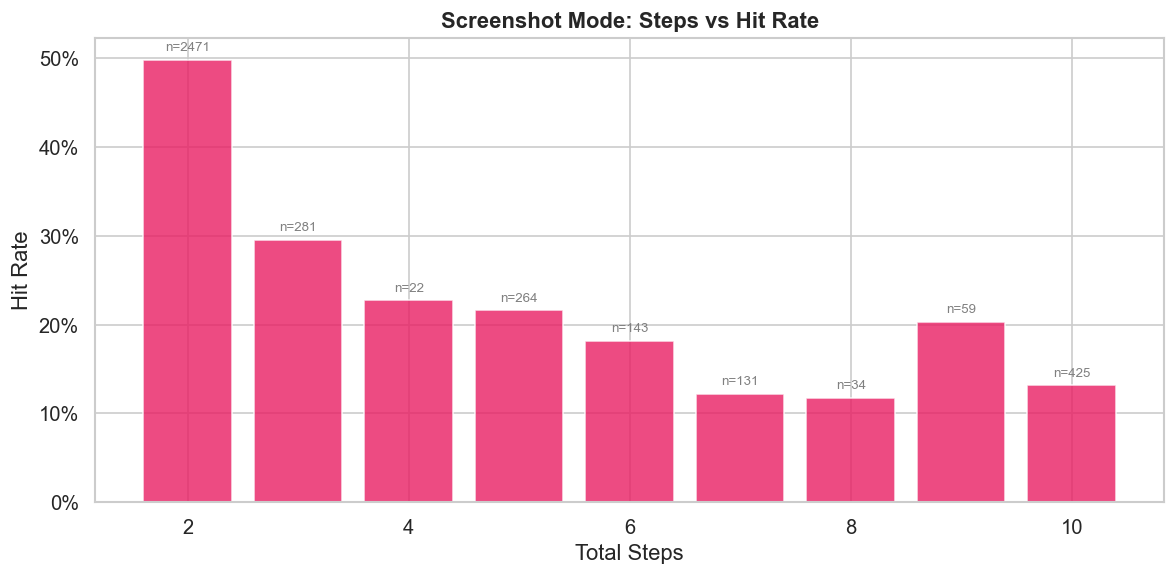

In [19]:
# Screenshot mode: steps vs hit rate
ss = df[df['inputMode']=='screenshot']
sh = ss.groupby('totalSteps')['choseTarget'].agg(['mean','count']).reset_index()
sh = sh[sh['count']>=10]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(sh['totalSteps'], sh['mean'], color='#E91E63', alpha=0.8)
ax.set_xlabel('Total Steps')
ax.set_ylabel('Hit Rate')
ax.set_title('Screenshot Mode: Steps vs Hit Rate', fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
for _, r in sh.iterrows():
    ax.text(r['totalSteps'], r['mean']+0.01, f'n={int(r["count"])}', ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

---
## 12. Timing Analysis

/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/1525352160.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_t, x='inputMode', y='toolDurationSec', order=MODE_ORDER, ax=axes[0],
/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/1525352160.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ts = df_t.groupby(['inputMode','choseTarget'])['toolDurationSec'].mean().unstack('choseTarget')


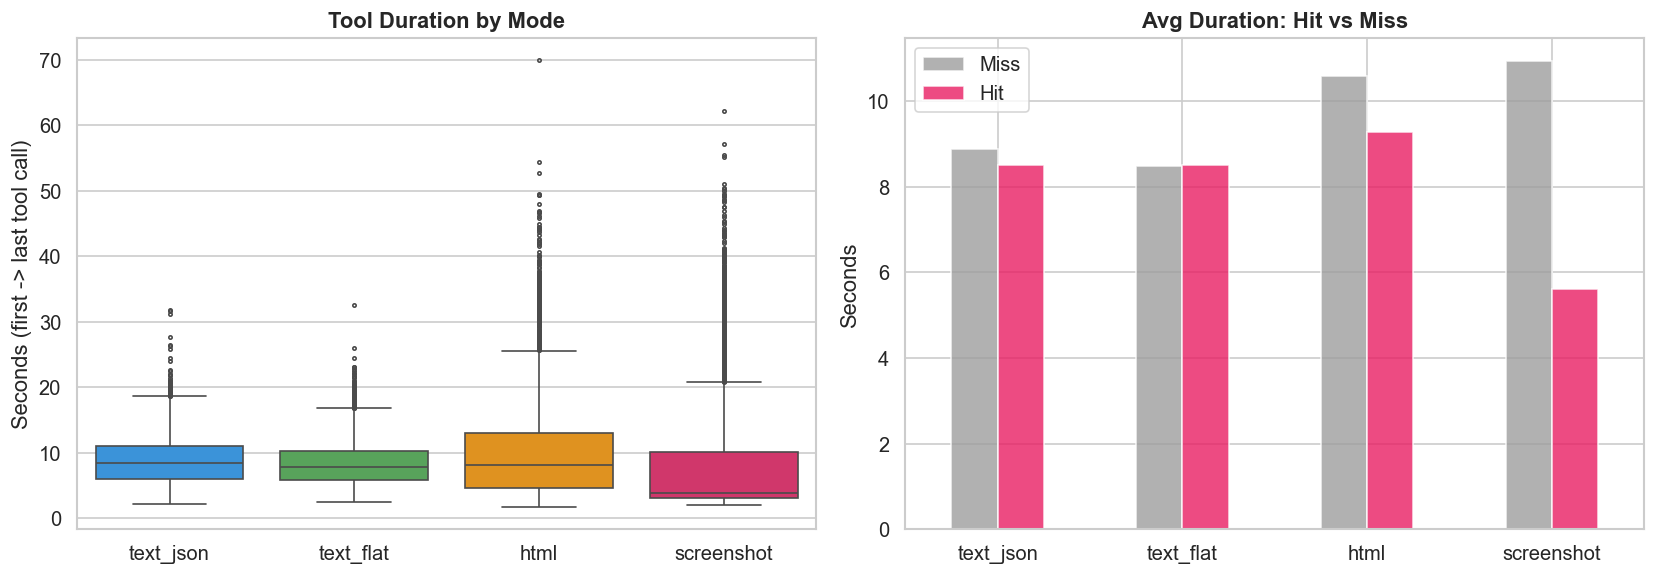

In [20]:
df_t = df.copy()
df_t['toolDurationSec'] = pd.to_numeric(df_t['toolDurationSec'], errors='coerce')
df_t = df_t[df_t['toolDurationSec'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_t, x='inputMode', y='toolDurationSec', order=MODE_ORDER, ax=axes[0],
            palette=[MODE_COLORS[m] for m in MODE_ORDER], fliersize=2)
axes[0].set_title('Tool Duration by Mode', fontweight='bold')
axes[0].set_ylabel('Seconds (first -> last tool call)')
axes[0].set_xlabel('')

ts = df_t.groupby(['inputMode','choseTarget'])['toolDurationSec'].mean().unstack('choseTarget')
ts.columns = ['Miss','Hit']
ts.reindex(MODE_ORDER).plot(kind='bar', ax=axes[1], color=['#9E9E9E','#E91E63'], alpha=0.8)
axes[1].set_title('Avg Duration: Hit vs Miss', fontweight='bold')
axes[1].set_ylabel('Seconds')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend()
plt.tight_layout()
plt.show()

---
## 13. Summary Table

In [21]:
summary = df.groupby(['condition','inputMode']).agg(
    n=('trialId','count'),
    hit_rate=('choseTarget','mean'),
    avg_steps=('totalSteps','mean'),
    avg_viewed=('numProductsViewed','mean'),
    avg_reviewed=('numReviewsRead','mean'),
    pct_viewed_target=('viewedTargetProduct','mean'),
    pct_reviewed_target=('reviewedTargetProduct','mean'),
    avg_cost=('estimatedCostUsd','mean'),
).reset_index()

summary.to_csv('../results/study2/study2_summary_stats.csv', index=False)
print('Saved: results/study2/study2_summary_stats.csv')
summary.style.format({
    'hit_rate':'{:.1%}', 'avg_steps':'{:.1f}', 'avg_viewed':'{:.1f}',
    'avg_reviewed':'{:.1f}', 'pct_viewed_target':'{:.0%}',
    'pct_reviewed_target':'{:.0%}', 'avg_cost':'${:.4f}'
})

Saved: results/study2/study2_summary_stats.csv


/var/folders/67/k4ct0mwx49j46bz5qfxg28_m0000gn/T/ipykernel_90512/4013827533.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(['condition','inputMode']).agg(


,condition,inputMode,n,hit_rate,avg_steps,avg_viewed,avg_reviewed,pct_viewed_target,pct_reviewed_target,avg_cost
0,control,text_json,480,10.6%,9.3,2.2,5.0,26%,60%,$0.0012
1,control,text_flat,480,12.1%,10.9,3.0,5.7,38%,69%,$0.0010
2,control,html,480,13.5%,7.7,1.4,4.3,15%,51%,$0.0020
3,control,screenshot,478,11.3%,3.8,0.1,1.7,1%,19%,$0.0201
4,scarcity,text_json,480,18.3%,9.2,2.2,4.9,35%,66%,$0.0011
5,scarcity,text_flat,479,14.2%,10.5,2.8,5.6,36%,68%,$0.0010
6,scarcity,html,479,17.3%,7.7,1.5,4.3,22%,56%,$0.0021
7,scarcity,screenshot,480,37.1%,3.9,0.1,1.8,2%,24%,$0.0197
8,social_proof_a,text_json,477,24.3%,9.1,2.2,4.9,41%,75%,$0.0012
9,social_proof_a,text_flat,479,14.8%,10.4,2.7,5.6,35%,71%,$0.0010
